In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/practice-hackathon/sample_submission.csv
/kaggle/input/practice-hackathon/Train.csv
/kaggle/input/practice-hackathon/Test.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [3]:
test = pd.read_csv('/kaggle/input/practice-hackathon/Test.csv')
test.head()

,Index,A,B,C,D,E,F,G,H
0,866,M,0.605,0.455,0.160,1.1035,0.4210,0.3015,0.325
1,1483,M,0.590,0.440,0.150,0.8725,0.3870,0.2150,0.245
2,599,F,0.560,0.445,0.195,0.9810,0.3050,0.2245,0.335
3,1702,F,0.635,0.490,0.170,1.2615,0.5385,0.2665,0.380
4,670,M,0.475,0.385,0.145,0.6175,0.2350,0.1080,0.215


In [4]:
train = pd.read_csv('/kaggle/input/practice-hackathon/Train.csv')
train.head()

,A,B,C,D,E,F,G,H,Target
0,F,0.615,0.455,0.135,1.0590,0.4735,0.2630,0.274,9
1,F,0.515,0.395,0.140,0.6860,0.2810,0.1255,0.220,12
2,M,0.660,0.530,0.175,1.5830,0.7395,0.3505,0.405,10
3,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
4,M,0.495,0.400,0.155,0.8085,0.2345,0.1155,0.350,6


In [5]:
combined = pd.concat([train,test])
combined.head()

,A,B,C,D,E,F,G,H,Target,Index
0,F,0.615,0.455,0.135,1.0590,0.4735,0.2630,0.274,9.0,NaN
1,F,0.515,0.395,0.140,0.6860,0.2810,0.1255,0.220,12.0,NaN
2,M,0.660,0.530,0.175,1.5830,0.7395,0.3505,0.405,10.0,NaN
3,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15.0,NaN
4,M,0.495,0.400,0.155,0.8085,0.2345,0.1155,0.350,6.0,NaN


In [6]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4177 entries, 0 to 1044
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       4177 non-null   object 
 1   B       4177 non-null   float64
 2   C       4177 non-null   float64
 3   D       4177 non-null   float64
 4   E       4177 non-null   float64
 5   F       4177 non-null   float64
 6   G       4177 non-null   float64
 7   H       4177 non-null   float64
 8   Target  3132 non-null   float64
 9   Index   1045 non-null   float64
dtypes: float64(9), object(1)
memory usage: 359.0+ KB


In [7]:
combined.dtypes

A          object
B         float64
C         float64
D         float64
E         float64
F         float64
G         float64
H         float64
Target    float64
Index     float64
dtype: object

In [8]:
combined.isnull().sum()/len(combined)*100

A          0.000000
B          0.000000
C          0.000000
D          0.000000
E          0.000000
F          0.000000
G          0.000000
H          0.000000
Target    25.017955
Index     74.982045
dtype: float64

In [9]:
combined.shape

(4177, 10)

In [10]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
B,4177.0,0.523992,0.120093,0.0750,0.4500,0.5450,0.615,0.8150
C,4177.0,0.407881,0.099240,0.0550,0.3500,0.4250,0.480,0.6500
D,4177.0,0.139516,0.041827,0.0000,0.1150,0.1400,0.165,1.1300
E,4177.0,0.828742,0.490389,0.0020,0.4415,0.7995,1.153,2.8255
F,4177.0,0.359367,0.221963,0.0010,0.1860,0.3360,0.502,1.4880
G,4177.0,0.180594,0.109614,0.0005,0.0935,0.1710,0.253,0.7600
H,4177.0,0.238831,0.139203,0.0015,0.1300,0.2340,0.329,1.0050
Target,3132.0,9.964879,3.229146,1.0000,8.0000,10.0000,11.000,29.0000
Index,1045.0,2024.866986,1210.261892,6.0000,1003.0000,2018.0000,3049.000,4176.0000


<Axes: >

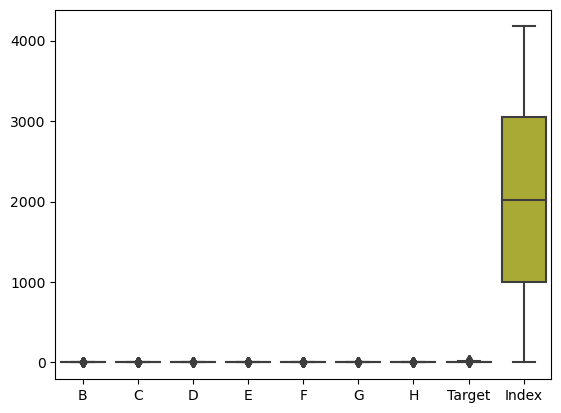

In [11]:
sns.boxplot(combined)

<Axes: >

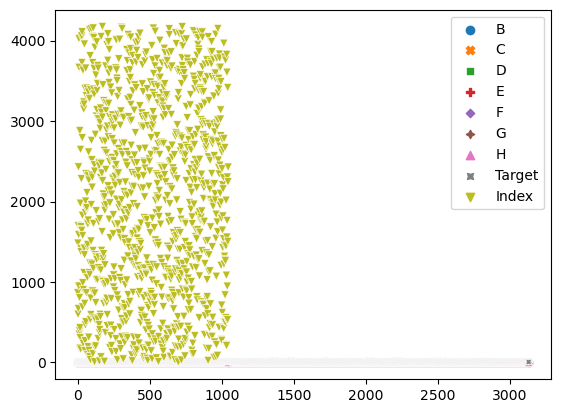

In [12]:
sns.scatterplot(combined)

In [13]:
Q1 = combined.quantile(0.25)
Q2 = combined.quantile(0.5)
Q3 = combined.quantile(0.75)
IQR=Q3-Q1
print(IQR)

B            0.1650
C            0.1300
D            0.0500
E            0.7115
F            0.3160
G            0.1595
H            0.1990
Target       3.0000
Index     2046.0000
dtype: float64


/tmp/ipykernel_33/2240195514.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = combined.quantile(0.25)
/tmp/ipykernel_33/2240195514.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q2 = combined.quantile(0.5)
/tmp/ipykernel_33/2240195514.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = combined.quantile(0.75)


In [14]:
UL = Q3+(1.5*IQR)
LL = Q1-(1.5*IQR)

In [15]:
combined_new = combined[~((combined<UL)|(combined>LL)).any(axis=1)]

/tmp/ipykernel_33/1567334620.py:1: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  combined_new = combined[~((combined<UL)|(combined>LL)).any(axis=1)]


In [16]:
combined_new.shape

(0, 10)

<Axes: >

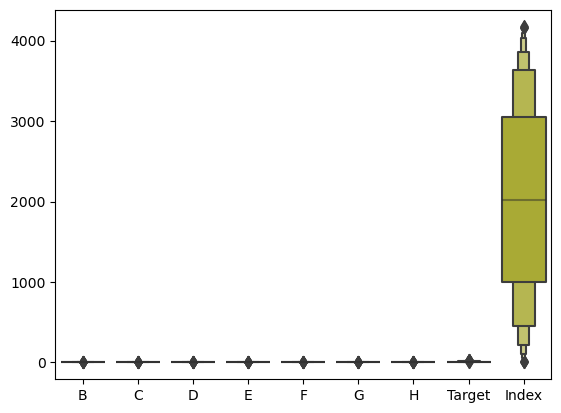

In [17]:
sns.boxenplot(combined)

<Axes: >

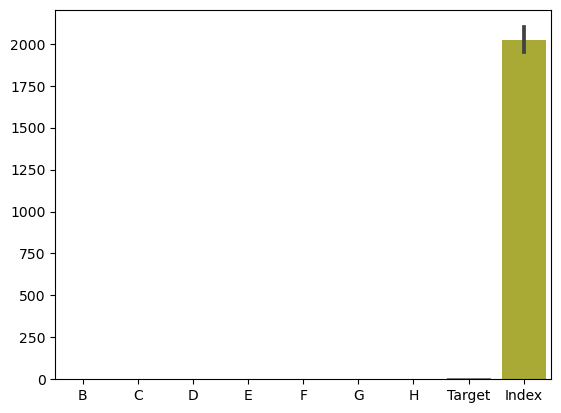

In [18]:
sns.barplot(combined)

<Axes: >

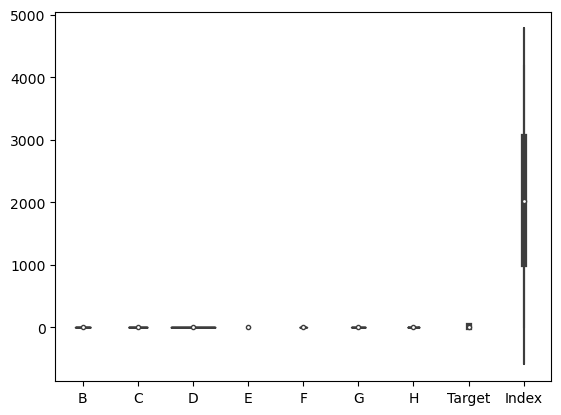

In [19]:
sns.violinplot(combined)

<Axes: ylabel='Density'>

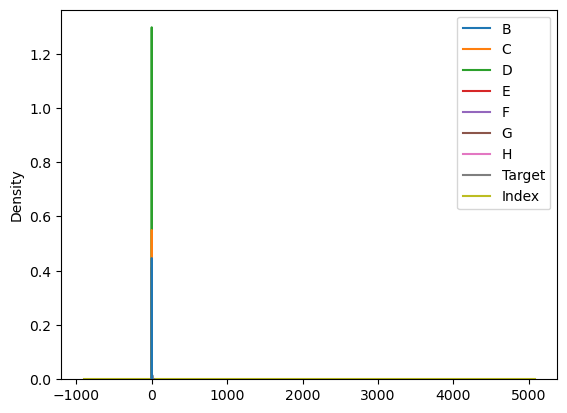

In [20]:
sns.kdeplot(combined)

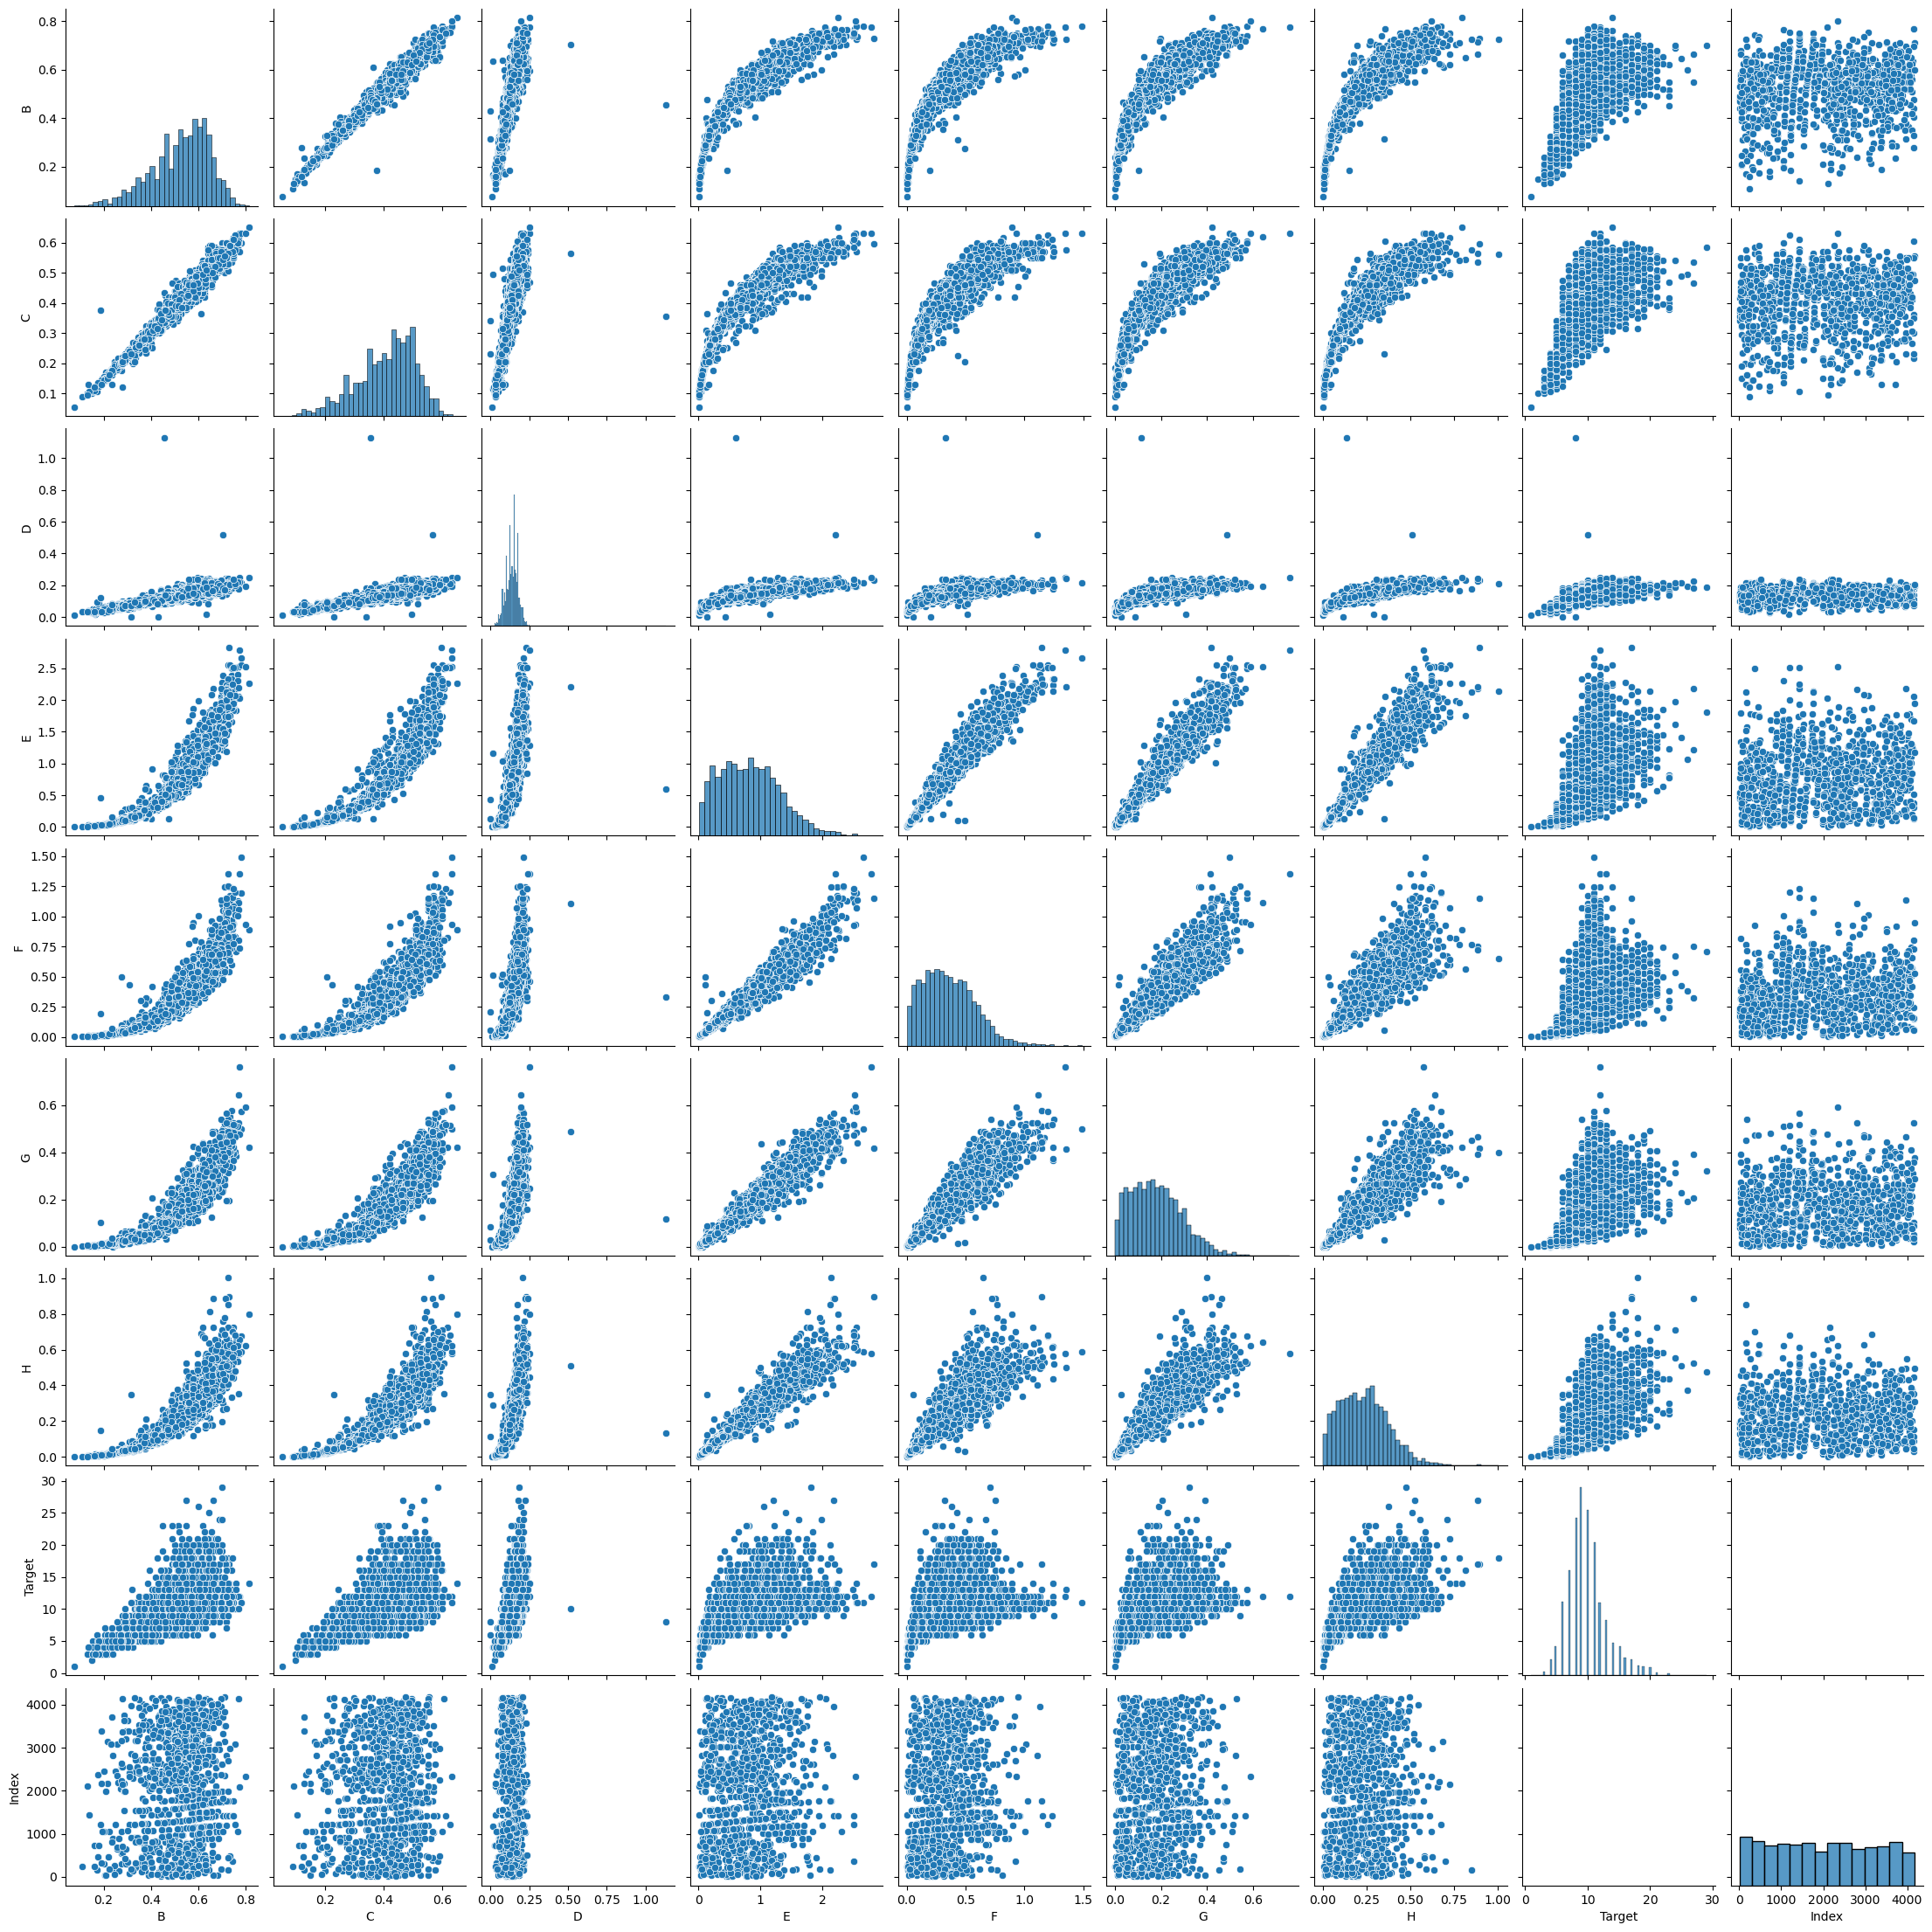

In [21]:
sns.pairplot(combined)

/tmp/ipykernel_33/1658940522.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True)


<Axes: >

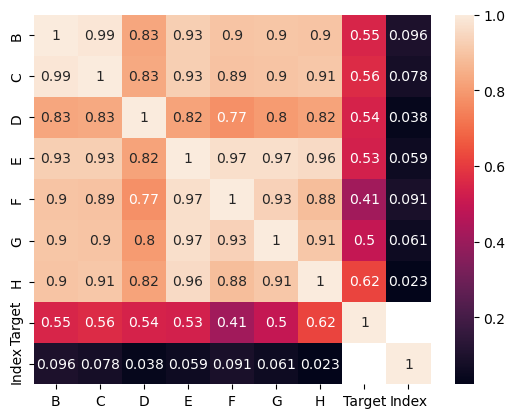

In [22]:
sns.heatmap(combined.corr(),annot=True)

In [23]:
cat_cols = combined.select_dtypes(include='object')

In [24]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

A
M    1528
I    1342
F    1307
Name: A, dtype: int64
__________________________________________________


In [25]:
num_cols = combined.select_dtypes(include='number')

In [26]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

B
0.625    94
0.550    94
0.575    93
0.580    92
0.620    87
         ..
0.150     1
0.815     1
0.135     1
0.110     1
0.800     1
Name: B, Length: 134, dtype: int64
__________________________________________________
C
0.450    139
0.475    120
0.400    111
0.500    110
0.470    100
        ... 
0.615      1
0.650      1
0.055      1
0.620      1
0.610      1
Name: C, Length: 111, dtype: int64
__________________________________________________
D
0.150    267
0.140    220
0.155    217
0.175    211
0.160    205
0.125    202
0.165    193
0.135    189
0.145    182
0.120    169
0.130    169
0.170    160
0.100    145
0.110    135
0.115    133
0.180    131
0.090    124
0.105    114
0.190    103
0.185    103
0.095     91
0.195     78
0.080     76
0.085     74
0.200     68
0.075     61
0.070     47
0.205     45
0.065     39
0.215     31
0.060     26
0.055     25
0.210     23
0.050     18
0.220     17
0.040     13
0.225     13
0.045     11
0.230     10
0.235      6
0.030      6
0.035      6
0

In [27]:
combined['B']=combined['B'].map({'Good':2,'Standard':1,'Poor':0})

/tmp/ipykernel_33/401063577.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')


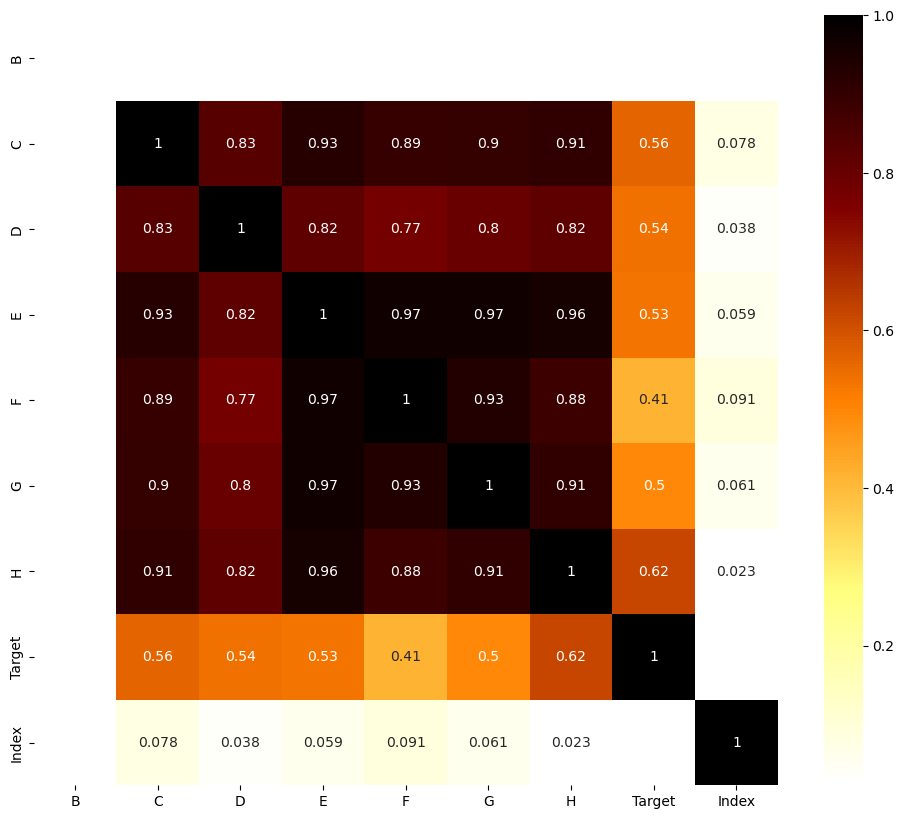

In [28]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

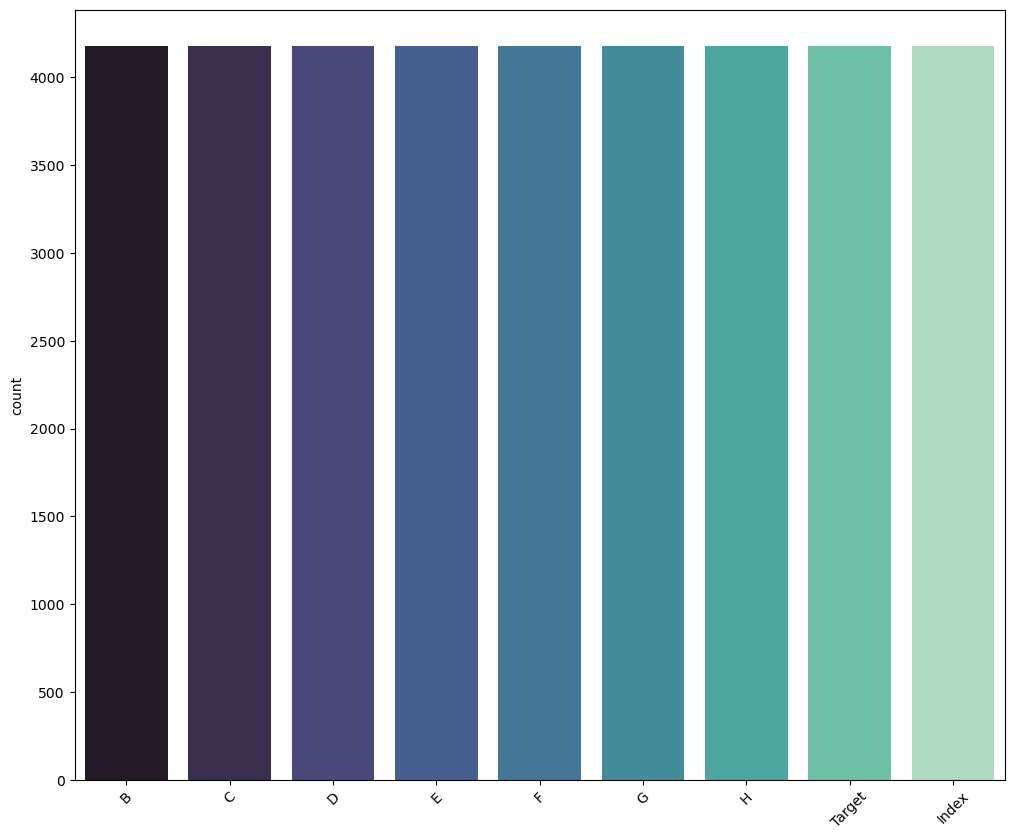

In [29]:
plt.figure(figsize=(12,10))
sns.countplot(combined,palette='mako');
plt.xticks(rotation=45);

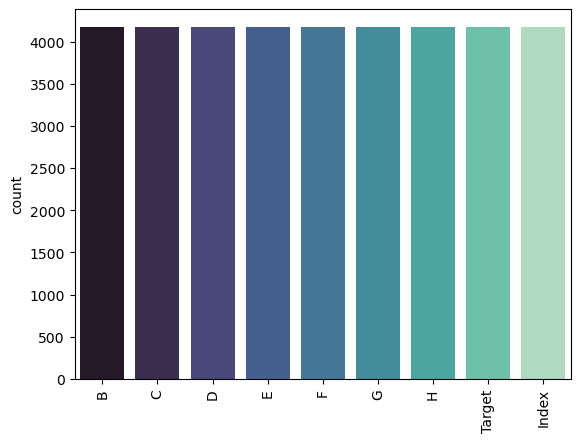

In [30]:
sns.countplot(combined,palette='mako');
plt.xticks(rotation=90);

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'B'),
  Text(1, 0, 'C'),
  Text(2, 0, 'D'),
  Text(3, 0, 'E'),
  Text(4, 0, 'F'),
  Text(5, 0, 'G'),
  Text(6, 0, 'H'),
  Text(7, 0, 'Target'),
  Text(8, 0, 'Index')])

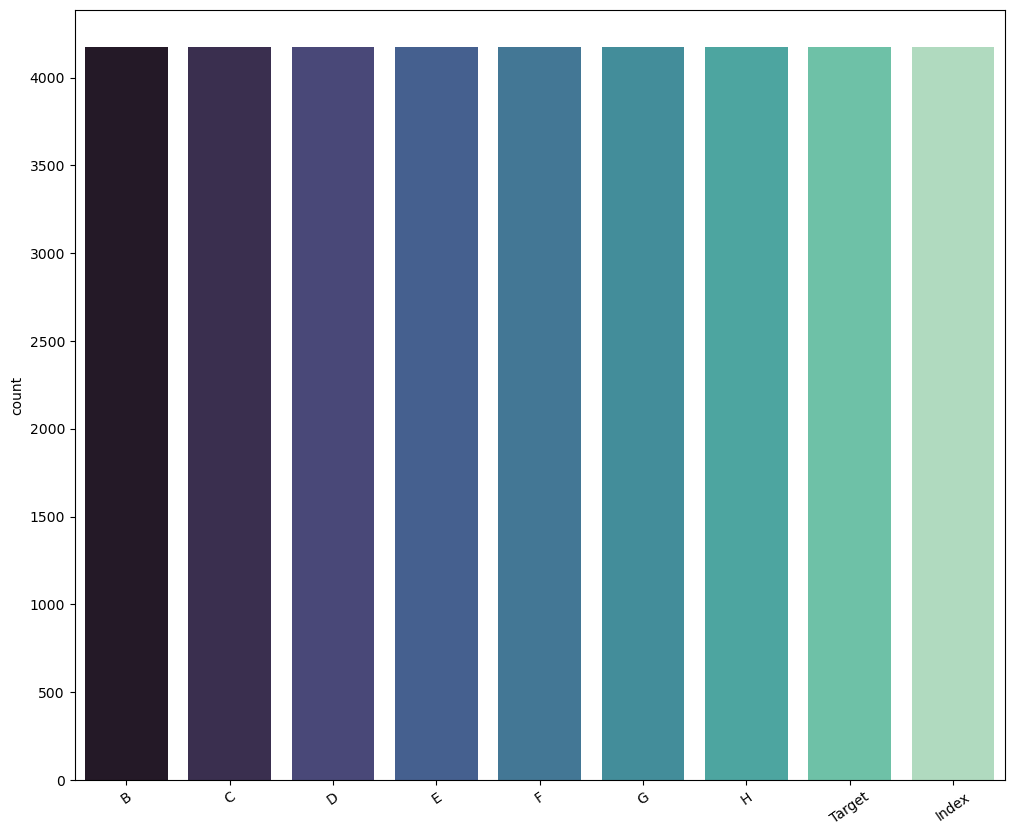

In [31]:
plt.figure(figsize=(12,10))
sns.countplot(combined,palette='mako')
plt.xticks(rotation=35)

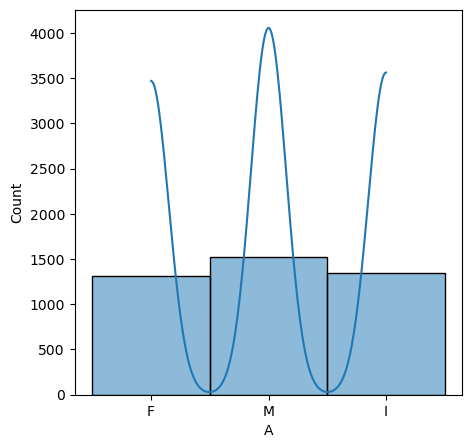

In [32]:
plt.figure(figsize=(5,5))
x=1
for i in cat_cols:
    sns.histplot(data=combined,x=i,kde=True)
    print('\n')
    plt.show()

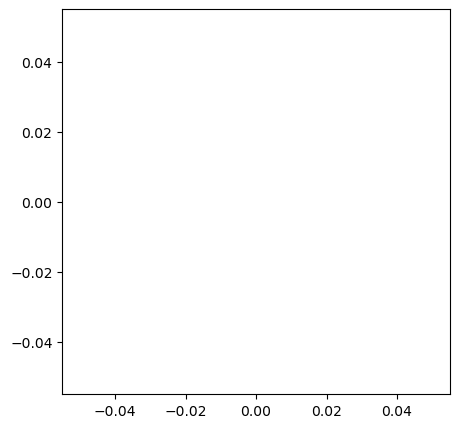

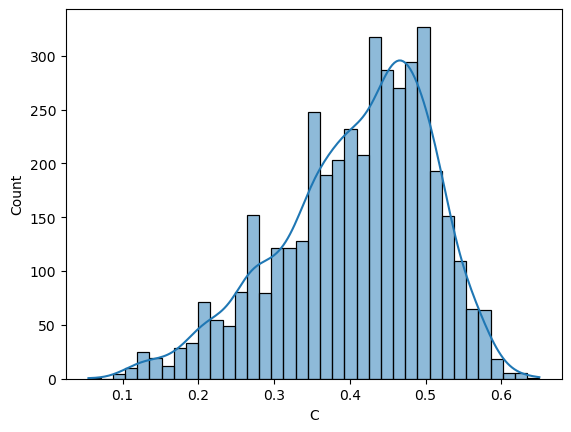

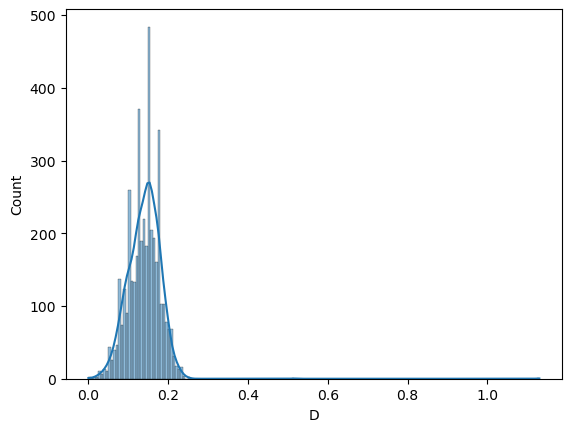

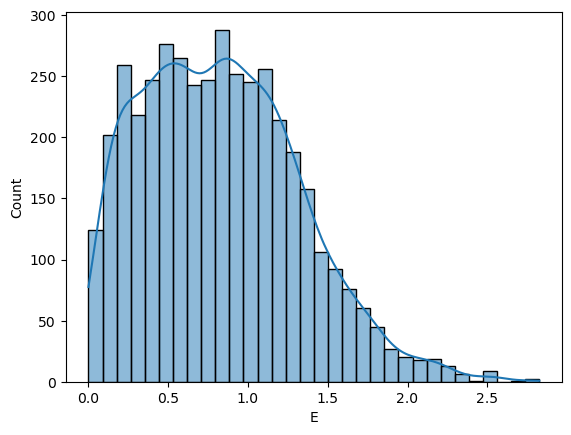

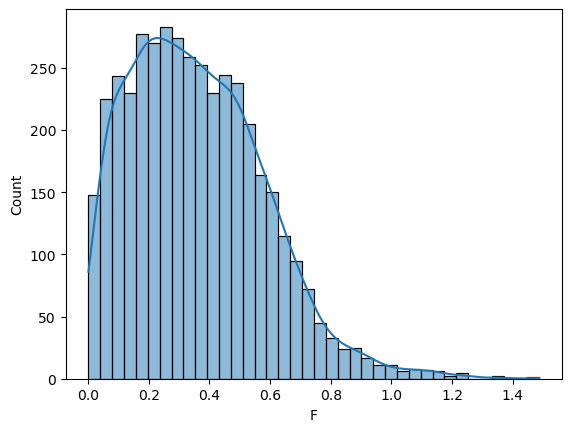

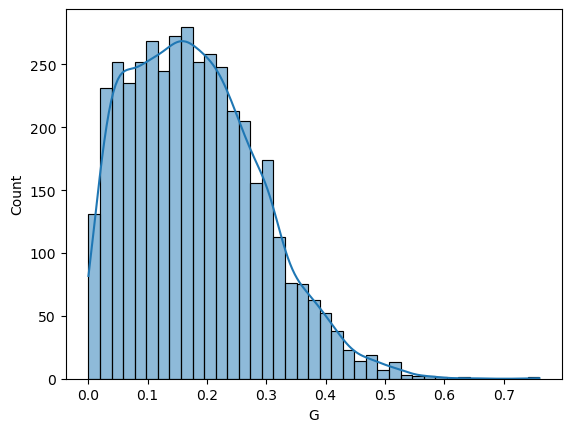

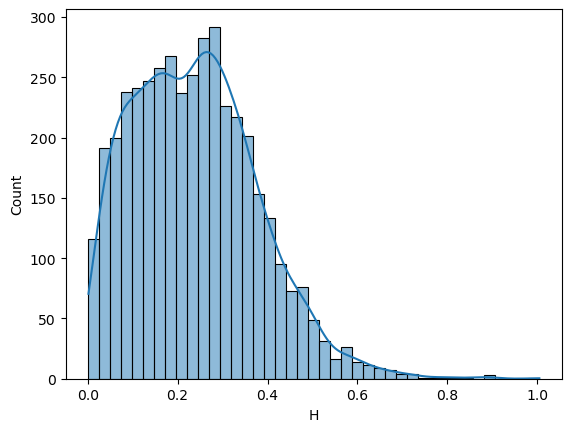

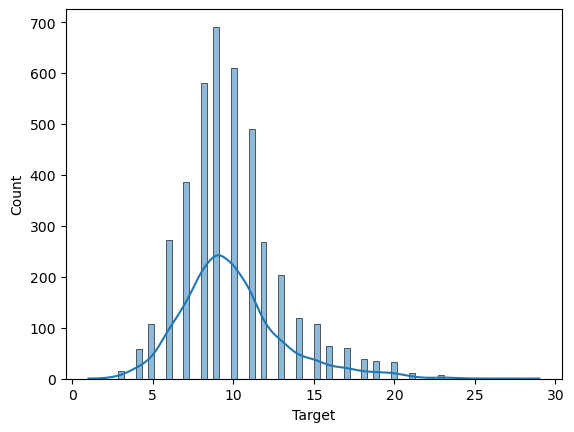

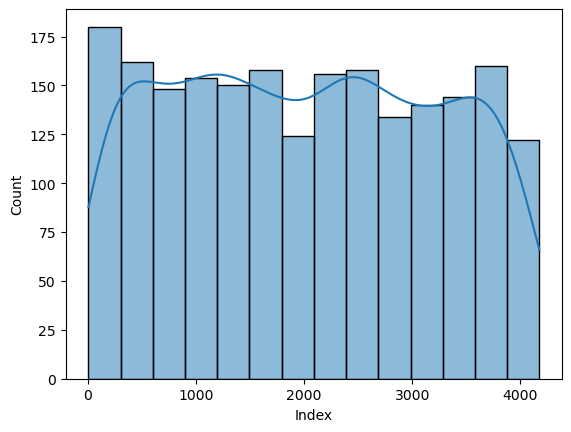

In [33]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.histplot(data=combined,x=i,kde=True)
    print('\n')
    plt.show()

In [34]:
combined['B'].value_counts()

Series([], Name: B, dtype: int64)

In [35]:
combined['B'].unique()

array([nan])

In [36]:
combined['B'].isnull().sum()

4177

In [ ]:
# Replacing weird values

In [40]:
combined = combined.applymap(lambda x: x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,"')
                            ).replace(['','nan','!@9#%8','#F%$D@*&8'],np.NaN)

In [41]:
combined.head()

,A,B,C,D,E,F,G,H,Target,Index
0,F,NaN,0.455,0.135,1.0590,0.4735,0.2630,0.274,9.0,NaN
1,F,NaN,0.395,0.140,0.6860,0.2810,0.1255,0.220,12.0,NaN
2,M,NaN,0.530,0.175,1.5830,0.7395,0.3505,0.405,10.0,NaN
3,M,NaN,0.365,0.095,0.5140,0.2245,0.1010,0.150,15.0,NaN
4,M,NaN,0.400,0.155,0.8085,0.2345,0.1155,0.350,6.0,NaN


In [42]:
# Treating type of C
combined['C'].value_counts().head(9).index[1:]

Float64Index([0.475, 0.4, 0.5, 0.47, 0.48, 0.455, 0.46, 0.44], dtype='float64')

In [49]:
combined.head()

,A,B,C,D,E,F,G,H,Target,Index
0,F,NaN,0.455,0.135,1.0590,0.4735,0.2630,0.274,9.0,NaN
1,F,NaN,0.395,0.140,0.6860,0.2810,0.1255,0.220,12.0,NaN
2,M,NaN,0.530,0.175,1.5830,0.7395,0.3505,0.405,10.0,NaN
3,M,NaN,0.365,0.095,0.5140,0.2245,0.1010,0.150,15.0,NaN
4,M,NaN,0.400,0.155,0.8085,0.2345,0.1155,0.350,6.0,NaN


In [ ]:
combined['C']=combined['C'].astype(int)

In [51]:
extreme=combined[(combined['C']>85)|(combined['C']<0)].index

In [52]:
for i in extreme:
    combined.loc[i,'C']=np.nan

In [53]:
combined.head()

,A,B,C,D,E,F,G,H,Target,Index
0,F,NaN,0.455,0.135,1.0590,0.4735,0.2630,0.274,9.0,NaN
1,F,NaN,0.395,0.140,0.6860,0.2810,0.1255,0.220,12.0,NaN
2,M,NaN,0.530,0.175,1.5830,0.7395,0.3505,0.405,10.0,NaN
3,M,NaN,0.365,0.095,0.5140,0.2245,0.1010,0.150,15.0,NaN
4,M,NaN,0.400,0.155,0.8085,0.2345,0.1155,0.350,6.0,NaN


In [54]:
mapping =combined.groupby('C')['D'].mean().to_dict()

In [55]:
combined['D']=combined['C'].map(mapping)

In [56]:
combined['D']=round(combined['D'],0)

In [57]:
combined['D']=combined['D'].astype(int)

In [59]:
combined.head()

,A,B,C,D,E,F,G,H,Target,Index
0,F,NaN,0.455,0,1.0590,0.4735,0.2630,0.274,9.0,NaN
1,F,NaN,0.395,0,0.6860,0.2810,0.1255,0.220,12.0,NaN
2,M,NaN,0.530,0,1.5830,0.7395,0.3505,0.405,10.0,NaN
3,M,NaN,0.365,0,0.5140,0.2245,0.1010,0.150,15.0,NaN
4,M,NaN,0.400,0,0.8085,0.2345,0.1155,0.350,6.0,NaN


In [60]:
combined.isnull().sum()

A            0
B         4177
C            0
D            0
E            0
F            0
G            0
H            0
Target    1045
Index     3132
dtype: int64

In [62]:
# Treating type of E
combined.groupby('A')['E'].apply(lambda x:x.fillna(x.mode()[0]))

/tmp/ipykernel_33/4082908303.py:2: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  combined.groupby('A')['E'].apply(lambda x:x.fillna(x.mode()[0]))


0       1.0590
0       1.1035
1       0.6860
1       0.8725
2       0.9810
         ...  
3127    0.5690
3128    1.3905
3129    0.5805
3130    1.0535
3131    1.1405
Name: E, Length: 4177, dtype: float64

In [63]:
cat_cols

,A
0,F
1,F
2,M
3,M
4,M
...,...
1040,I
1041,M
1042,M
1043,M


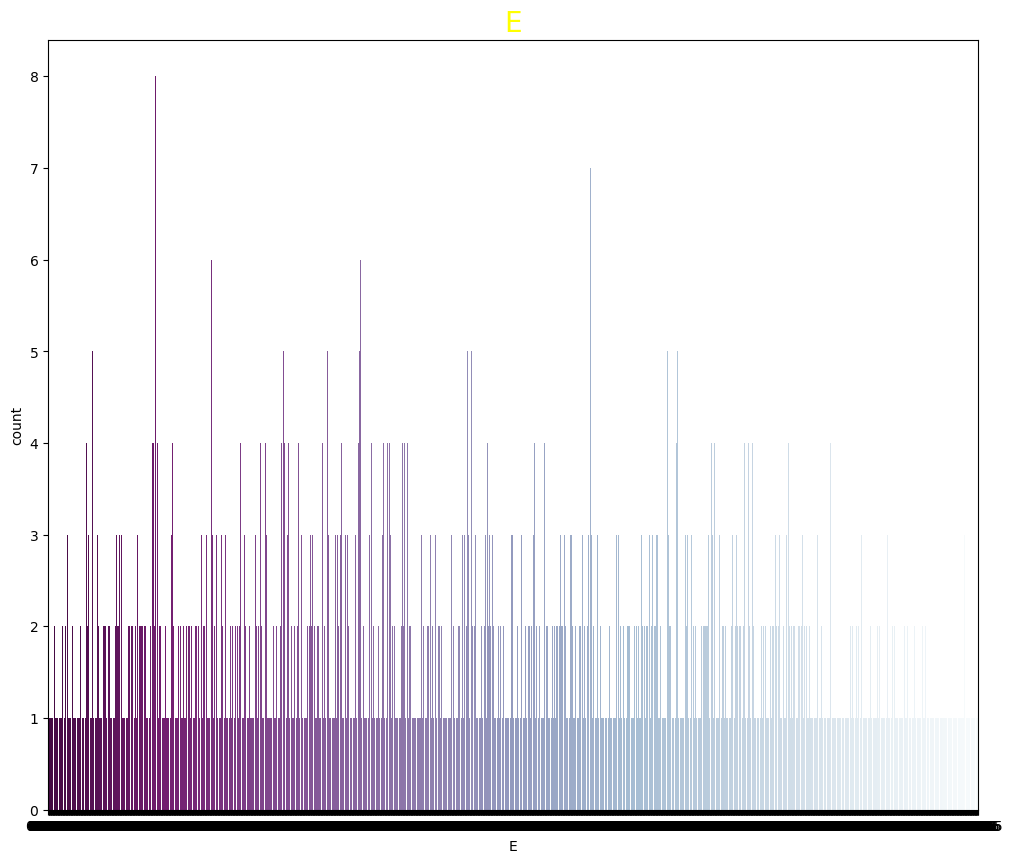

In [67]:
plt.figure(figsize=(12,10))
sns.countplot(data=combined,x='E',palette='BuPu_r')
plt.title('E',size=20,color='Yellow')
plt.show()

In [68]:
combined['E'].value_counts(normalize=True)*100

0.2225    0.191525
1.1345    0.167584
0.1960    0.167584
0.4775    0.167584
0.9700    0.167584
            ...   
0.2690    0.023941
0.8305    0.023941
1.8385    0.023941
0.8980    0.023941
0.6695    0.023941
Name: E, Length: 2429, dtype: float64

In [70]:
combined.head()

,A,B,C,D,E,F,G,H,Target,Index
0,F,NaN,0.455,0,1.0590,0.4735,0.2630,0.274,9.0,NaN
1,F,NaN,0.395,0,0.6860,0.2810,0.1255,0.220,12.0,NaN
2,M,NaN,0.530,0,1.5830,0.7395,0.3505,0.405,10.0,NaN
3,M,NaN,0.365,0,0.5140,0.2245,0.1010,0.150,15.0,NaN
4,M,NaN,0.400,0,0.8085,0.2345,0.1155,0.350,6.0,NaN


In [71]:
train.shape[0]

3132

In [72]:
new_train=combined.iloc[0:train.shape[0],:]

In [73]:
new_test=combined.iloc[train.shape[0]:,:]

In [74]:
train.shape,new_train.shape,test.shape,new_test.shape

((3132, 9), (3132, 10), (1045, 9), (1045, 10))

In [78]:
import scipy.stats as stats

In [79]:
num_cols = combined.select_dtypes(include='object')
cat_cols = combined.select_dtypes(include='number')

In [83]:
new_train


,A,B,C,D,E,F,G,H,Target,Index
0,F,NaN,0.455,0,1.0590,0.4735,0.2630,0.274,9.0,NaN
1,F,NaN,0.395,0,0.6860,0.2810,0.1255,0.220,12.0,NaN
2,M,NaN,0.530,0,1.5830,0.7395,0.3505,0.405,10.0,NaN
3,M,NaN,0.365,0,0.5140,0.2245,0.1010,0.150,15.0,NaN
4,M,NaN,0.400,0,0.8085,0.2345,0.1155,0.350,6.0,NaN
...,...,...,...,...,...,...,...,...,...,...
3127,F,NaN,0.400,0,0.5690,0.2560,0.1325,0.145,9.0,NaN
3128,F,NaN,0.550,0,1.3905,0.5425,0.3035,0.400,12.0,NaN
3129,M,NaN,0.395,0,0.5805,0.2440,0.1335,0.188,11.0,NaN
3130,M,NaN,0.465,0,1.0535,0.5160,0.2185,0.235,9.0,NaN


In [84]:

new_test

,A,B,C,D,E,F,G,H,Target,Index
0,M,NaN,0.455,0,1.1035,0.4210,0.3015,0.325,NaN,866.0
1,M,NaN,0.440,0,0.8725,0.3870,0.2150,0.245,NaN,1483.0
2,F,NaN,0.445,0,0.9810,0.3050,0.2245,0.335,NaN,599.0
3,F,NaN,0.490,0,1.2615,0.5385,0.2665,0.380,NaN,1702.0
4,M,NaN,0.385,0,0.6175,0.2350,0.1080,0.215,NaN,670.0
...,...,...,...,...,...,...,...,...,...,...
1040,I,NaN,0.370,0,0.4705,0.1845,0.1055,0.155,NaN,532.0
1041,M,NaN,0.460,0,1.0165,0.4910,0.2210,0.265,NaN,3417.0
1042,M,NaN,0.510,0,1.3080,0.5440,0.3180,0.377,NaN,1505.0
1043,M,NaN,0.375,0,0.5105,0.1920,0.1045,0.205,NaN,2245.0


In [ ]:
# scaling the col

In [91]:
scaling=[]

In [92]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [93]:
for i in scaling:
    new_train.loc[:,i]=scaler.fit_transform(pd.DataFrame(new_train.loc[:,i]))
    new_test.loc[:,i]=scaler.transform(pd.DataFrame(new_test.loc[:,i]))

In [ ]:
# Encoding

In [94]:
train_encoded=pd.get_dummies(new_train,drop_first=True)

In [95]:
test_encoded=pd.get_dummies(new_test,drop_first=True)

In [96]:
train_encoded

,B,C,D,E,F,G,H,Target,Index,A_I,A_M
0,NaN,0.455,0,1.0590,0.4735,0.2630,0.274,9.0,NaN,0,0
1,NaN,0.395,0,0.6860,0.2810,0.1255,0.220,12.0,NaN,0,0
2,NaN,0.530,0,1.5830,0.7395,0.3505,0.405,10.0,NaN,0,1
3,NaN,0.365,0,0.5140,0.2245,0.1010,0.150,15.0,NaN,0,1
4,NaN,0.400,0,0.8085,0.2345,0.1155,0.350,6.0,NaN,0,1
...,...,...,...,...,...,...,...,...,...,...,...
3127,NaN,0.400,0,0.5690,0.2560,0.1325,0.145,9.0,NaN,0,0
3128,NaN,0.550,0,1.3905,0.5425,0.3035,0.400,12.0,NaN,0,0
3129,NaN,0.395,0,0.5805,0.2440,0.1335,0.188,11.0,NaN,0,1
3130,NaN,0.465,0,1.0535,0.5160,0.2185,0.235,9.0,NaN,0,1
